<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/20_regularization/20_1_Practical_Training/20_1_1_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularization: Part 1
## Dropout

---

## What This Notebook Is About

In notebook 19_1_2 you trained a deliberately oversized network — two hidden layers of 256 units each — on the Wisconsin Breast Cancer data and watched it overfit. The training loss collapsed toward zero while the validation loss bottomed out and then started climbing back up. The model was **memorizing** the training samples instead of learning patterns that generalize. You could see the problem in the loss curves, but you had no tool to fight it.

This notebook gives you that tool. **Dropout** is the most widely used regularization technique in deep learning, and the idea behind it is almost suspiciously simple: during training, randomly switch off a fraction of the neurons on every forward pass. A network that never knows which neurons will be available cannot afford to lean too hard on any single one of them, so it is forced to spread what it learns across many redundant paths. That redundancy is exactly what makes the model generalize better.

Along the way we will settle a piece of unfinished business from module 19. You were told to call `model.train()` and `model.eval()`, and that these "affect layers like Dropout and BatchNorm," but never *why*. By the end of this notebook you will understand exactly what those two calls do to a dropout layer and why forgetting them is one of the most common bugs in PyTorch.

**What you will learn:**
1. What dropout does and why randomly removing neurons reduces overfitting
2. How to place `nn.Dropout` correctly in an architecture
3. Why `model.train()` and `model.eval()` are non-optional once dropout is in the network
4. How to tune the dropout rate `p` by reading validation loss curves

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import seaborn as sns
sns.set_theme(style='whitegrid')
torch.manual_seed(42)

# Load the Wisconsin Breast Cancer dataset (same as 19_1_2)
data  = load_breast_cancer()
X_raw = data.data.astype(np.float32)    # 569 samples x 30 features
y_raw = data.target.astype(np.float32)  # 0=malignant, 1=benign

# Three-way split: 60% train / 20% val / 20% test (same recipe as 19_1_2).
# Validation guides our choice of dropout rate; the test set stays untouched
# until the very end so it can give an unbiased final estimate.
X_tmp, X_test_np, y_tmp, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42
)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=42  # 0.25 x 0.80 = 0.20
)

# Standardize: fit on training data only, then transform all three splits
scaler     = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_val_np   = scaler.transform(X_val_np)
X_test_np  = scaler.transform(X_test_np)

# Convert to tensors; targets are shape (n, 1) to match the network's output
X_train = torch.tensor(X_train_np)
X_val   = torch.tensor(X_val_np)
X_test  = torch.tensor(X_test_np)
y_train = torch.tensor(y_train_np).unsqueeze(1)
y_val   = torch.tensor(y_val_np).unsqueeze(1)
y_test  = torch.tensor(y_test_np).unsqueeze(1)

BATCH_SIZE   = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print(f'Features: {X_train.shape[1]}')

Train : 341 samples
Val   : 114 samples
Test  : 114 samples
Features: 30


---

## Section 1: The Problem Dropout Solves

Let's reproduce the overfitting from 19_1_2. We build the same oversized (256, 256) network and train it for 300 epochs — long enough to memorize the training set.

First, a training helper. It is the same canonical loop you used in 19_1_2: for each epoch we put the model in **training mode**, run through the mini-batches (`zero_grad → forward → loss → backward → step`), then put the model in **evaluation mode** to measure the validation loss without updating anything. Hold onto those `model.train()` and `model.eval()` calls — we dissect them in Section 3.

In [2]:
def train_and_track(model, optimizer, n_epochs):
    """Train a binary classifier, returning per-epoch train and validation loss."""
    criterion = nn.BCELoss()
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        # --- training phase ---
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        # --- validation phase (no gradient updates) ---
        model.eval()
        with torch.no_grad():
            val_losses.append(criterion(model(X_val), y_val).item())

    return train_losses, val_losses

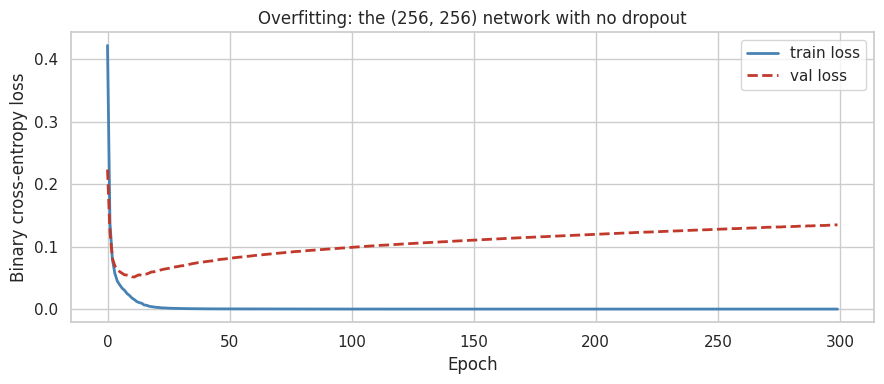

Train loss at epoch 300 : 0.0000
Best validation loss    : 0.0513  (epoch 12)
Validation loss at end  : 0.1348  (epoch 300)


In [3]:
class OverfitNet(nn.Module):
    """The oversized (256, 256) network from 19_1_2 - no regularization."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
baseline = OverfitNet()
optimizer = torch.optim.Adam(baseline.parameters(), lr=1e-3)
base_train, base_val = train_and_track(baseline, optimizer, n_epochs=300)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(base_train, label='train loss', color='steelblue', lw=2)
ax.plot(base_val,   label='val loss',   color='#C0392B',   lw=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary cross-entropy loss')
ax.set_title('Overfitting: the (256, 256) network with no dropout')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Train loss at epoch 300 : {base_train[-1]:.4f}')
print(f'Best validation loss    : {min(base_val):.4f}  (epoch {int(np.argmin(base_val)) + 1})')
print(f'Validation loss at end  : {base_val[-1]:.4f}  (epoch 300)')

Look at the gap. The training loss slides almost to zero — the network has essentially memorized the training tumors. The validation loss tells a different story: it reaches its best value early, then **drifts back upward** as training continues. The printout makes this concrete — the validation loss *ends* far higher than its best value, because every epoch past that point the model is fitting noise in the training set rather than signal. That widening gap between the two curves is the visual signature of **overfitting**, the same bias-variance pattern you saw with deep decision trees in unit 18_6.

So here is the question that motivates dropout: what if, during each training step, we randomly removed some neurons? No neuron could be counted on to always be there, so the network would have to learn the same patterns in several redundant ways. That redundancy is what we are after.

---

## Section 2: `nn.Dropout(p)` in Practice

`nn.Dropout(p)` is a layer like any other. On each forward pass it independently zeros out each incoming value with probability `p` — so `p=0.3` means roughly 30% of the activations are switched off. The values that survive are scaled up by `1 / (1 - p)` so that the overall magnitude flowing through the layer stays about the same.

Two rules of placement:

- **Put dropout *after* the activation function, never before.** The standard block is `Linear → ReLU → Dropout`.
- Typical values for `p` run from **0.2 to 0.5**. Higher means more aggressive regularization.

Here is dropout acting on a simple all-ones vector so you can see which entries get zeroed and how the survivors are scaled up:

In [4]:
torch.manual_seed(0)
drop   = nn.Dropout(p=0.3)
sample = torch.ones(10)

drop.train()  # dropout is active in training mode
print('input:        ', sample.numpy())
print('after dropout:', drop(sample).numpy())
print('\nSurviving values are 1 / (1 - 0.3) = 1.43, not 1.0 - that is the scaling at work.')

input:         [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
after dropout: [0.        0.        1.4285715 0.        1.4285715 0.        1.4285715
 1.4285715 1.4285715 1.4285715]

Surviving values are 1 / (1 - 0.3) = 1.43, not 1.0 - that is the scaling at work.


---

## Section 3: Why `model.train()` and `model.eval()` Matter

This is the piece module 19 kept promising to explain. A dropout layer behaves **differently in the two modes**:

- In **training mode** (`model.train()`) dropout is *active*: it randomly zeros activations on every forward pass. That randomness is the whole point — it is what regularizes the network.
- In **evaluation mode** (`model.eval()`) dropout is *disabled*: every neuron is used, and the output is completely deterministic.

This matters enormously at inference time. If you forget to call `model.eval()` before making predictions, dropout stays on and your model gives a *different answer every time you call it* — and each answer is based on a randomly crippled version of the network. The demonstration below makes the difference concrete: the same input, run five times in each mode.

In [5]:
drop   = nn.Dropout(p=0.3)
sample = torch.ones(8)

print('TRAINING mode - active, stochastic (different every call):')
drop.train()
for i in range(5):
    print(f'  call {i + 1}: {drop(sample).numpy()}')

print('\nEVAL mode - disabled, deterministic (identical every call):')
drop.eval()
for i in range(5):
    print(f'  call {i + 1}: {drop(sample).numpy()}')

TRAINING mode - active, stochastic (different every call):
  call 1: [1.4285715 1.4285715 1.4285715 1.4285715 1.4285715 1.4285715 1.4285715
 1.4285715]
  call 2: [1.4285715 0.        1.4285715 1.4285715 1.4285715 1.4285715 1.4285715
 1.4285715]
  call 3: [1.4285715 1.4285715 0.        1.4285715 0.        1.4285715 1.4285715
 1.4285715]
  call 4: [1.4285715 0.        1.4285715 1.4285715 0.        1.4285715 1.4285715
 1.4285715]
  call 5: [0.        1.4285715 1.4285715 1.4285715 0.        1.4285715 0.
 0.       ]

EVAL mode - disabled, deterministic (identical every call):
  call 1: [1. 1. 1. 1. 1. 1. 1. 1.]
  call 2: [1. 1. 1. 1. 1. 1. 1. 1.]
  call 3: [1. 1. 1. 1. 1. 1. 1. 1.]
  call 4: [1. 1. 1. 1. 1. 1. 1. 1.]
  call 5: [1. 1. 1. 1. 1. 1. 1. 1.]


The stochastic behavior **is** the regularization; the determinism **is** the inference requirement. During training you want the noise. At prediction time you want a single, stable answer. The `model.train()` / `model.eval()` switch is how you ask for each.

Forgetting it is one of the most common — and most quietly damaging — PyTorch bugs, because the code still runs; it just gives you randomly worse predictions. This is the concrete reason behind the habit you formed in 19_1_2.

---

## Section 4: Dropout in the Overfit Network

Now we put dropout to work. This is the same (256, 256) architecture as before, but with an `nn.Dropout` layer after each ReLU. Everything else — optimizer, learning rate, number of epochs — is held fixed, so the only thing that changed is the regularization.

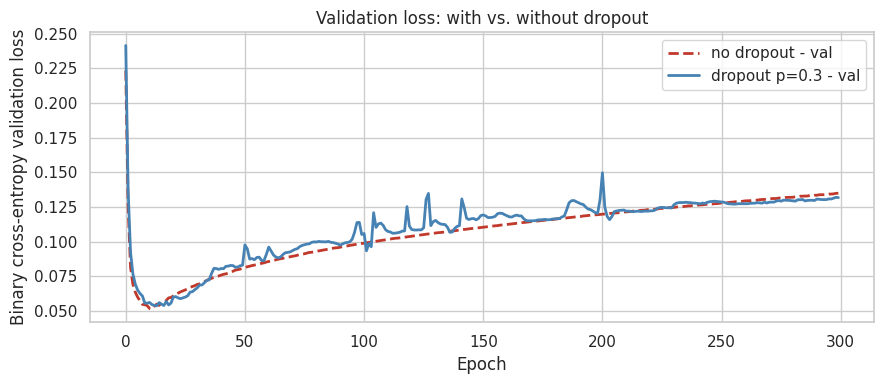

                          no dropout   dropout p=0.3
best validation loss   :    0.0513        0.0537
validation loss at end :    0.1348        0.1317
train loss at end      :    0.0000        0.0000


In [6]:
class RegularizedNet(nn.Module):
    """The same (256, 256) network, now with dropout after each activation."""
    def __init__(self, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 256), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(256, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
reg = RegularizedNet(dropout_p=0.3)
reg_optimizer = torch.optim.Adam(reg.parameters(), lr=1e-3)
reg_train, reg_val = train_and_track(reg, reg_optimizer, n_epochs=300)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(base_val, label='no dropout - val',     color='#C0392B', lw=2, linestyle='--')
ax.plot(reg_val,  label='dropout p=0.3 - val',  color='steelblue', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary cross-entropy validation loss')
ax.set_title('Validation loss: with vs. without dropout')
ax.legend()
plt.tight_layout()
plt.show()

print('                          no dropout   dropout p=0.3')
print(f'best validation loss   :    {min(base_val):.4f}        {min(reg_val):.4f}')
print(f'validation loss at end :    {base_val[-1]:.4f}        {reg_val[-1]:.4f}')
print(f'train loss at end      :    {base_train[-1]:.4f}        {reg_train[-1]:.4f}')

Read that table carefully, because it does **not** say what you might expect.

- The **best** validation loss is essentially unchanged. Both models, at their best moment, are about equally good — dropout did not find a lower floor.
- The **end-of-training** loss is *also* essentially unchanged: at `p = 0.3`, the dropout model drifts upward almost exactly as far as the baseline.
- The **training loss still collapses to zero.** This is the tell. With 74,000 parameters and only 341 training samples — about 217 parameters per sample — the network has so much spare capacity that it memorizes the training set *through* the dropout noise. Randomly losing 30% of its neurons on each pass barely slows it down.

So is dropout useless? No — but this is an honest result worth sitting with: **at the textbook rate, on a network this oversized relative to its data, dropout alone does not stop late-stage memorization.** Two things follow. First, the rate matters, and the next section sweeps it. Second, on a problem like this dropout needs a partner: the checkpointing and early stopping of 20_1_4 capture the best epoch no matter what the curve does afterwards, and 20_1_5 combines all the tools. Dropout earns its reputation on larger datasets and deeper networks, where it is routinely the difference between overfitting and not; here you are watching it hit its limits.

---

## Section 5: The Dropout-Rate Trade-off

`p` is a knob you have to tune. Too small and you barely regularize — the validation loss still climbs late in training. Too large and you can cripple the network so badly it cannot even fit the training data well; this is **underfitting**. Let's train the same architecture at three different rates and compare the validation curves against the no-dropout baseline. We tune `p` on the **validation** set — the test set stays untouched.

A single end-of-training number is a noisy way to judge a rate — on a 114-sample validation set, one overconfident mistake moves the loss a lot. So the code below reports two summaries per rate: the **best** validation loss the run ever reached, and the **average over the last 50 epochs** (how the run behaves late in training).

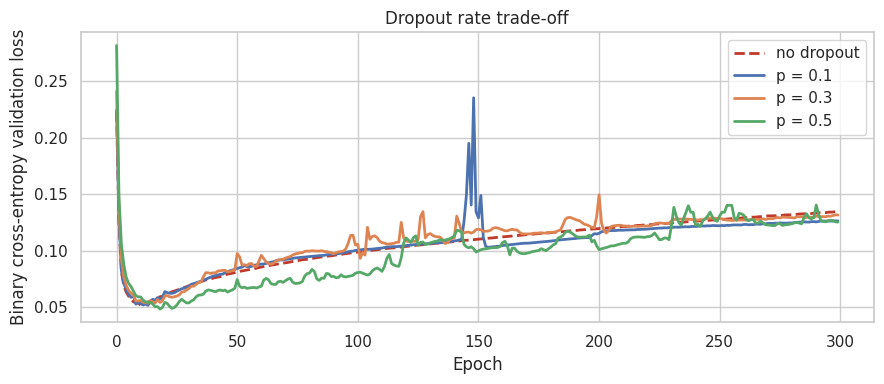

rate          best val   mean of last 50
no dropout      0.0513            0.1313
p = 0.1         0.0517            0.1245
p = 0.3         0.0537            0.1290
p = 0.5         0.0484            0.1279

Rate with the lowest best validation loss: p = 0.5


In [7]:
rates  = [0.1, 0.3, 0.5]
curves = {}
for p in rates:
    torch.manual_seed(42)
    model = RegularizedNet(dropout_p=p)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    _, val = train_and_track(model, opt, n_epochs=300)
    curves[p] = val

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(base_val, label='no dropout', color='#C0392B', lw=2, linestyle='--')
for p in rates:
    ax.plot(curves[p], lw=2, label=f'p = {p}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary cross-entropy validation loss')
ax.set_title('Dropout rate trade-off')
ax.legend()
plt.tight_layout()
plt.show()

print(f'{"rate":<12}{"best val":>10}{"mean of last 50":>18}')
print(f'{"no dropout":<12}{min(base_val):>10.4f}{np.mean(base_val[-50:]):>18.4f}')
for p in rates:
    print(f'{f"p = {p}":<12}{min(curves[p]):>10.4f}{np.mean(curves[p][-50:]):>18.4f}')

best_p = min(rates, key=lambda p: min(curves[p]))
print(f'\nRate with the lowest best validation loss: p = {best_p}')

Reading these curves is the skill to take away. Compare each colored line against the dashed no-dropout baseline:

- **Mid-training, more dropout holds the loss lower.** Through roughly epochs 50–200 the `p = 0.5` curve sits visibly below the others, and it also posts the lowest *best* loss — the strongest rate slows memorization the most.
- **By epoch 300, every configuration has drifted into the same band.** No rate *prevents* the late climb on this network: with ~217 parameters per training sample, the network eventually memorizes the training set through any amount of dropout we tried.
- **No underfitting in sight** — even `p = 0.5` still drives the training loss to essentially zero here, again because the network is so oversized. On a smaller network or a harder dataset, `p = 0.5` can genuinely starve learning; that is the other side of the trade-off to watch for.

The standard guidance — **start at p = 0.3–0.4 and let the validation curves tell you which way to move** — remains the right default for networks that are not this extravagantly oversized. Here the curves say: move *up*, and bring reinforcements (early stopping, notebook 20_1_4).

---

## Section 6: Final Evaluation on the Test Set

We used the validation set to choose the dropout rate, so — exactly as in 19_1_2 — validation performance is now slightly optimistic and cannot be our reported result. We retrain the chosen model on the combined train+validation data and evaluate once on the **test set**, which has been untouched until this moment.

Note the `model.eval()` call before prediction: now that the network contains dropout layers, skipping it would let dropout corrupt every test prediction.

In [8]:
# Combine train + validation for the final fit
X_trainval = torch.cat([X_train, X_val])
y_trainval = torch.cat([y_train, y_val])
trainval_loader = DataLoader(
    TensorDataset(X_trainval, y_trainval), batch_size=BATCH_SIZE, shuffle=True
)

torch.manual_seed(42)
final_model = RegularizedNet(dropout_p=best_p)
final_optim = torch.optim.Adam(final_model.parameters(), lr=1e-3)
final_crit  = nn.BCELoss()

for epoch in range(300):
    final_model.train()
    for X_b, y_b in trainval_loader:
        final_optim.zero_grad()
        loss = final_crit(final_model(X_b), y_b)
        loss.backward()
        final_optim.step()

final_model.eval()  # REQUIRED: turn dropout off before predicting
with torch.no_grad():
    test_preds  = (final_model(X_test) > 0.5).long().squeeze().numpy()
    test_labels = y_test.long().squeeze().numpy()

print(f'Final model: RegularizedNet with dropout p = {best_p}')
print()
print(classification_report(test_labels, test_preds, target_names=data.target_names, digits=3))

Final model: RegularizedNet with dropout p = 0.5

              precision    recall  f1-score   support

   malignant      0.911     0.976     0.943        42
      benign      0.986     0.944     0.965        72

    accuracy                          0.956       114
   macro avg      0.948     0.960     0.954       114
weighted avg      0.958     0.956     0.956       114



---

## Putting It All Together

| Concept | What it means |
|---|---|
| Dropout | Randomly zeros a fraction `p` of activations during training, forcing redundant, more generalizable representations |
| `nn.Dropout(p)` | The layer that implements dropout; `p` is the probability of zeroing each unit |
| Placement | After the activation: `Linear → ReLU → Dropout` |
| Dropout rate `p` | Tunable knob; 0.2–0.5 typical, 0.3–0.4 a good starting point |
| `model.train()` | Dropout *active* and stochastic — the regularization is on |
| `model.eval()` | Dropout *disabled* and deterministic — required before prediction |
| What dropout did here | Slowed the late climb (most visibly at p = 0.5) but could not stop memorization at ~217 parameters per sample — pair it with early stopping (20_1_4) |
| Underfitting | Too much dropout: the network cannot even fit the training data |

**The one habit to lock in:** any network with dropout *must* be switched to `model.eval()` before you make predictions, or every prediction is based on a randomly crippled network. The code will not error — it will just be quietly wrong.

**What is coming next:** Notebook 20_1_2 adds **batch normalization**, which stabilizes training and allows higher learning rates. It also requires the train/eval mode switch — for a different reason — and stacks neatly with dropout in the standard block `Linear → BatchNorm → ReLU → Dropout`.